
# Week 4: Xception Transfer Learning

## Project
**Automated Casting Defect Detection Using Deep Learning and Computer Vision**

## Week 4 Objective
The aim of Week 4 is to move beyond the Week 3 Custom CNN baseline and train the main transfer-learning model using **Xception**. This week uses ImageNet-pretrained convolutional features, adds a custom binary classification head, freezes the Xception backbone, trains the classification head, and evaluates the model on validation data.

## Team Contributions

| Member | Name | Role | Week 4 Contribution |
|---|---|---|---|
| Member 1 | Sandeep Bommagoni | Data & EDA Lead | Reused the clean dataset workflow, verified split consistency and calculated class weights |
| Member 2 | Likith Kumar Devulapalli | Architecture / Xception Lead | Built the Xception transfer-learning architecture and custom classification head |
| Member 3 | Raghava Krishna Battu | Model Comparison Lead | Added callbacks, checkpointing, training setup and comparison with Week 3 baseline |
| Member 4 | Navatej Patel Cheerneni | Evaluation & XAI Lead | Evaluated Xception using validation metrics, training curves and confusion matrix |
| Member 5 | Tharun Chinnachinnaiahgari | GitHub / Deployment Lead | Saved results, metadata, Week 4 summary and GitHub evidence |



## 1. Import Libraries

**Contributor:** Tharun Chinnachinnaiahgari  
This section imports the libraries required for transfer learning, model training, evaluation, plotting and saving evidence files.


In [4]:

# Contributor: Tharun Chinnachinnaiahgari
# Task: Import libraries and set random seeds

import os
import json
import random
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
)

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")


TensorFlow version: 2.17.0
Libraries imported successfully.



## 2. Configuration and Output Folders

**Contributor:** Tharun Chinnachinnaiahgari  
Xception commonly uses 299 × 299 image inputs. Therefore, Week 4 uses 299 × 299 images instead of the Week 3 baseline size.


In [5]:

# Contributor: Tharun Chinnachinnaiahgari
# Task: Configure paths, labels, image size and output folders

DATASET_ROOT = Path("/kaggle/input/real-life-industrial-dataset-of-casting-product")

IMAGE_SIZE = (299, 299)
BATCH_SIZE = 24
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15

LABEL_TO_ID = {"ok_front": 0, "def_front": 1}
ID_TO_LABEL = {0: "ok_front", 1: "def_front"}

OUTPUT_DIR = Path("/kaggle/working/week4_xception_transfer_learning")
MODEL_DIR = OUTPUT_DIR / "models"
PLOT_DIR = OUTPUT_DIR / "plots"
REPORT_DIR = OUTPUT_DIR / "reports"

for folder in [OUTPUT_DIR, MODEL_DIR, PLOT_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Dataset root:", DATASET_ROOT)
print("Output directory:", OUTPUT_DIR)
print("Image size:", IMAGE_SIZE)
print("Label mapping:", ID_TO_LABEL)


Dataset root: /kaggle/input/real-life-industrial-dataset-of-casting-product
Output directory: /kaggle/working/week4_xception_transfer_learning
Image size: (299, 299)
Label mapping: {0: 'ok_front', 1: 'def_front'}



## 3. Dataset Source and Clean Manifest

**Contributor:** Sandeep Bommagoni  
The same clean dataset approach from Week 3 is reused so that the Xception model can be compared fairly with the baseline CNN.


In [6]:

# Contributor: Sandeep Bommagoni
# Task: Discover dataset source and create clean image manifest

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

def discover_class_pairs(root: Path):
    pairs = []
    for def_dir in root.rglob("def_front"):
        parent = def_dir.parent
        if (parent / "ok_front").is_dir():
            pairs.append(parent)
    return sorted(set(pairs))

class_pairs = discover_class_pairs(DATASET_ROOT)

if not class_pairs:
    raise FileNotFoundError(f"No valid dataset folder found under {DATASET_ROOT}")

raw_512_pairs = [p for p in class_pairs if "512" in str(p).lower()]
selected_source = raw_512_pairs[0] if raw_512_pairs else class_pairs[0]

print("Selected dataset source:", selected_source)

records = []

for label_name, label_id in LABEL_TO_ID.items():
    class_dir = selected_source / label_name

    for path in sorted(class_dir.iterdir()):
        if path.is_file() and path.suffix.lower() in SUPPORTED_EXTENSIONS:
            image = cv2.imread(str(path))
            records.append({
                "path": str(path),
                "filename": path.name,
                "label_name": label_name,
                "label": label_id,
                "readable": image is not None,
                "height": None if image is None else image.shape[0],
                "width": None if image is None else image.shape[1],
            })

manifest = pd.DataFrame(records)

print("Total files found:", len(manifest))
print("Unreadable files:", int((~manifest["readable"]).sum()))

manifest = manifest[manifest["readable"]].reset_index(drop=True)

display(manifest.groupby("label_name").size().reset_index(name="image_count"))
display(manifest.head())

manifest.to_csv(REPORT_DIR / "week4_clean_image_manifest.csv", index=False)


Selected dataset source: /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_512x512/casting_512x512
Total files found: 1300
Unreadable files: 0


,label_name,image_count
0,def_front,781
1,ok_front,519


,path,filename,label_name,label,readable,height,width
0,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_1018.jpeg,ok_front,0,True,512,512
1,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_1021.jpeg,ok_front,0,True,512,512
2,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_1028.jpeg,ok_front,0,True,512,512
3,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_1074.jpeg,ok_front,0,True,512,512
4,/kaggle/input/real-life-industrial-dataset-of-...,cast_ok_0_1082.jpeg,ok_front,0,True,512,512



## 4. Train / Validation / Test Split and Class Weights

**Contributor:** Sandeep Bommagoni  
A stratified split is used. The validation set is used for Week 4 model evaluation. The test set is preserved for later final evaluation.


In [7]:

# Contributor: Sandeep Bommagoni
# Task: Create stratified splits and calculate class weights

train_df, temp_df = train_test_split(
    manifest,
    train_size=TRAIN_FRACTION,
    stratify=manifest["label"],
    random_state=SEED,
)

validation_ratio_from_temp = VALIDATION_FRACTION / (VALIDATION_FRACTION + TEST_FRACTION)

validation_df, test_df = train_test_split(
    temp_df,
    train_size=validation_ratio_from_temp,
    stratify=temp_df["label"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_manifest = pd.concat([
    train_df.assign(split="train"),
    validation_df.assign(split="validation"),
    test_df.assign(split="test"),
], ignore_index=True)

split_counts = split_manifest.groupby(["split", "label_name"]).size().reset_index(name="images")
display(split_counts)

split_manifest.to_csv(REPORT_DIR / "week4_train_validation_test_manifest.csv", index=False)
split_counts.to_csv(REPORT_DIR / "week4_split_counts.csv", index=False)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].to_numpy(),
)

CLASS_WEIGHTS = {
    0: float(class_weight_values[0]),
    1: float(class_weight_values[1]),
}

print("Class weights:", CLASS_WEIGHTS)

with open(REPORT_DIR / "week4_class_weights.json", "w") as f:
    json.dump(CLASS_WEIGHTS, f, indent=4)


,split,label_name,images
0,test,def_front,118
1,test,ok_front,78
2,train,def_front,546
3,train,ok_front,363
4,validation,def_front,117
5,validation,ok_front,78


Class weights: {0: 1.2520661157024793, 1: 0.8324175824175825}



## 5. TensorFlow Dataset Pipeline for Xception

**Contributor:** Likith Kumar Devulapalli  
This creates the TensorFlow input pipeline. Images are decoded, resized to 299 × 299, batched and prefetched.


In [8]:

# Contributor: Likith Kumar Devulapalli
# Task: Build TensorFlow dataset pipeline for Xception

AUTOTUNE = tf.data.AUTOTUNE

def decode_and_resize(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE, antialias=True)
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.float32)

def make_dataset(dataframe: pd.DataFrame, training: bool) -> tf.data.Dataset:
    paths = dataframe["path"].astype(str).to_numpy()
    labels = dataframe["label"].astype(np.float32).to_numpy()

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE, drop_remainder=False)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset

train_ds = make_dataset(train_df, training=True)
validation_ds = make_dataset(validation_df, training=False)
test_ds = make_dataset(test_df, training=False)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image value range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))


Image batch shape: (24, 299, 299, 3)
Label batch shape: (24,)
Image value range: 3.527736186981201 to 255.00006103515625



## 6. Build Xception Transfer-Learning Model

**Contributor:** Likith Kumar Devulapalli  
Xception is used as a frozen feature extractor. A custom classification head is added for binary casting defect classification.


In [9]:

# Contributor: Likith Kumar Devulapalli
# Task: Build Xception transfer-learning model

def make_augmentation():
    return keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.04, fill_mode="reflect"),
            layers.RandomZoom(0.08, fill_mode="reflect"),
            layers.RandomContrast(0.10),
            layers.RandomBrightness(0.08, value_range=(0, 255)),
        ],
        name="augmentation",
    )

def load_xception_backbone():
    try:
        backbone = keras.applications.Xception(
            include_top=False,
            weights="imagenet",
            input_shape=IMAGE_SIZE + (3,),
            pooling="avg",
            name="xception",
        )
        print("Loaded ImageNet-pretrained Xception weights.")
    except Exception as error:
        print("Could not load ImageNet weights. Falling back to random initialisation.")
        print("Reason:", error)
        backbone = keras.applications.Xception(
            include_top=False,
            weights=None,
            input_shape=IMAGE_SIZE + (3,),
            pooling="avg",
            name="xception",
        )
    return backbone

def build_xception_transfer_model():
    inputs = keras.Input(shape=IMAGE_SIZE + (3,), name="image")

    x = make_augmentation()(inputs)
    x = keras.applications.xception.preprocess_input(x)

    backbone = load_xception_backbone()
    backbone.trainable = False

    x = backbone(x, training=False)
    x = layers.BatchNormalization(name="head_batch_norm")(x)
    x = layers.Dense(256, activation="relu", name="head_dense_256")(x)
    x = layers.Dropout(0.35, name="head_dropout")(x)

    outputs = layers.Dense(1, activation="sigmoid", name="probability_defective")(x)

    model = keras.Model(inputs, outputs, name="Week4_Xception_TransferLearning")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="defect_precision"),
            keras.metrics.Recall(name="defect_recall"),
            keras.metrics.AUC(name="roc_auc", curve="ROC"),
            keras.metrics.AUC(name="pr_auc", curve="PR"),
        ],
    )

    return model

xception_model = build_xception_transfer_model()
xception_model.summary()


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loaded ImageNet-pretrained Xception weights.


Model: "Week4_Xception_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                   │ (None, 299, 299, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ augmentation (Sequential)            │ (None, 299, 299, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 299, 299, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 299, 299, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xception (Functional)                │ (None, 2048)                │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_batch_norm (BatchNormalization) │ (None, 2048)                │           8,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_dense_256 (Dense)               │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ head_dropout (Dropout)               │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ probability_defective (Dense)        │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,394,473 (81.61 MB)

 Trainable params: 528,897 (2.02 MB)

 Non-trainable params: 20,865,576 (79.60 MB)


## 7. Train Xception Classification Head

**Contributor:** Raghava Krishna Battu  
This trains only the custom head while the Xception backbone remains frozen. This is the standard first stage of transfer learning.


In [ ]:

# Contributor: Raghava Krishna Battu
# Task: Train Xception transfer-learning model with callbacks

EPOCHS = 12

callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_DIR / "week4_xception_best.keras",
        monitor="val_pr_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(REPORT_DIR / "week4_xception_training_log.csv"),
]

start_time = time.time()

history = xception_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks,
    verbose=1,
)

training_time = time.time() - start_time
print(f"Training time: {training_time/60:.2f} minutes")


Epoch 1/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9657 - defect_precision: 0.9808 - defect_recall: 0.9618 - loss: 0.0801 - pr_auc: 0.9977 - roc_auc: 0.9963
Epoch 2: val_pr_auc improved from 0.97742 to 0.99159, saving model to /kaggle/working/week4_xception_transfer_learning/models/week4_xception_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step - accuracy: 0.9658 - defect_precision: 0.9809 - defect_recall: 0.9618 - loss: 0.0802 - pr_auc: 0.9976 - roc_auc: 0.9963 - val_accuracy: 0.7385 - val_defect_precision: 0.6964 - val_defect_recall: 1.0000 - val_loss: 0.4323 - val_pr_auc: 0.9916 - val_roc_auc: 0.9858 - learning_rate: 0.0010
Epoch 3/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9825 - defect_precision: 0.9877 - defect_recall: 0.9832 - loss: 0.0554 - pr_auc: 0.9990 - roc_auc: 0.9985
Epoch 3: val_pr_auc improved from 0.99159 to 0.99890, saving model to /kaggle/working/week4_xception_transfer_learning/models/week4_xception_best.keras
38/38 ━━━━━━━━━━━━━━━━━


## 8. Training Curves

**Contributor:** Navatej Patel Cheerneni  
Training curves show how Xception learns over time and whether overfitting appears.


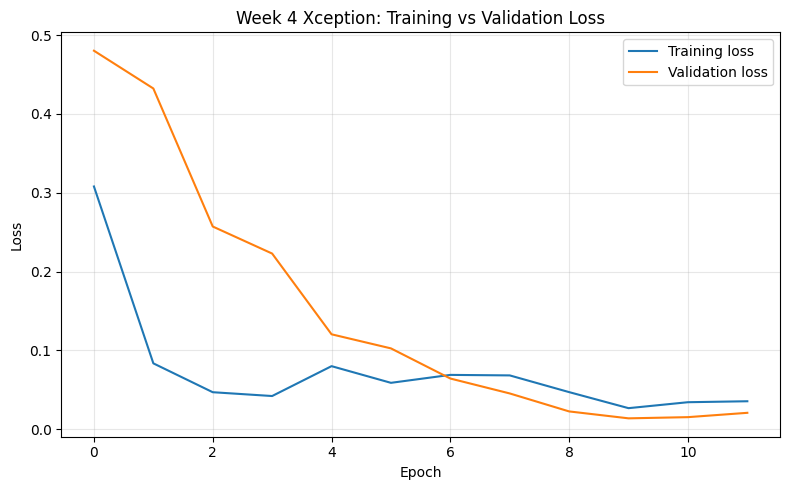

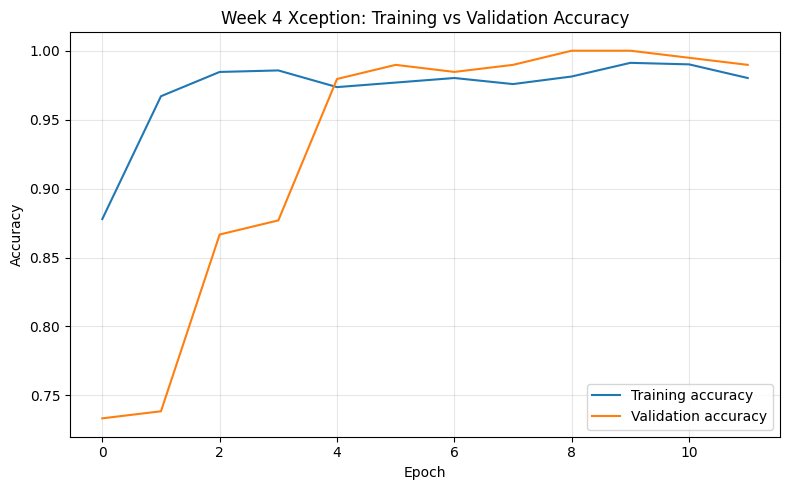

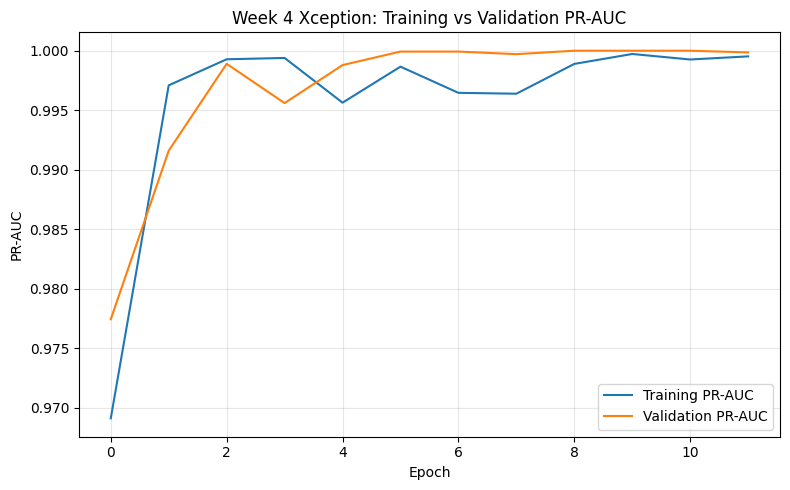

In [16]:

# Contributor: Navatej Patel Cheerneni
# Task: Plot Xception training curves

history_df = pd.DataFrame(history.history)
history_df.to_csv(REPORT_DIR / "week4_xception_history.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["loss"], label="Training loss")
ax.plot(history_df["val_loss"], label="Validation loss")
ax.set_title("Week 4 Xception: Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "week4_xception_loss.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["accuracy"], label="Training accuracy")
ax.plot(history_df["val_accuracy"], label="Validation accuracy")
ax.set_title("Week 4 Xception: Training vs Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "week4_xception_accuracy.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["pr_auc"], label="Training PR-AUC")
ax.plot(history_df["val_pr_auc"], label="Validation PR-AUC")
ax.set_title("Week 4 Xception: Training vs Validation PR-AUC")
ax.set_xlabel("Epoch")
ax.set_ylabel("PR-AUC")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "week4_xception_pr_auc.png", dpi=160)
plt.show()



## 9. Xception Validation Evaluation

**Contributor:** Navatej Patel Cheerneni  
The model is evaluated using accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC and confusion matrix.


In [17]:

# Contributor: Navatej Patel Cheerneni
# Task: Evaluate Xception model on validation data

def collect_labels(dataset):
    return np.concatenate([labels.numpy().reshape(-1) for _, labels in dataset]).astype(int)

def collect_probabilities(model, dataset):
    return model.predict(dataset, verbose=0).reshape(-1)

y_val = collect_labels(validation_ds)
val_probabilities = collect_probabilities(xception_model, validation_ds)
val_predictions = (val_probabilities >= 0.5).astype(int)

xception_metrics = {
    "threshold": 0.5,
    "accuracy": float(accuracy_score(y_val, val_predictions)),
    "defect_precision": float(precision_score(y_val, val_predictions, pos_label=1, zero_division=0)),
    "defect_recall": float(recall_score(y_val, val_predictions, pos_label=1, zero_division=0)),
    "f1_defect": float(f1_score(y_val, val_predictions, pos_label=1, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_val, val_probabilities)),
    "pr_auc": float(average_precision_score(y_val, val_probabilities)),
    "training_minutes": float(training_time / 60),
}

print("Xception validation metrics:")
print(json.dumps(xception_metrics, indent=4))

with open(REPORT_DIR / "week4_xception_validation_metrics.json", "w") as f:
    json.dump(xception_metrics, f, indent=4)

report_dict = classification_report(
    y_val,
    val_predictions,
    target_names=["ok_front", "def_front"],
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).transpose()
display(report_df)
report_df.to_csv(REPORT_DIR / "week4_xception_classification_report.csv")

cm = confusion_matrix(y_val, val_predictions, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["Actual ok_front", "Actual def_front"], columns=["Pred ok_front", "Pred def_front"])
display(cm_df)
cm_df.to_csv(REPORT_DIR / "week4_xception_confusion_matrix.csv")


Xception validation metrics:
{
    "threshold": 0.5,
    "accuracy": 1.0,
    "defect_precision": 1.0,
    "defect_recall": 1.0,
    "f1_defect": 1.0,
    "roc_auc": 1.0,
    "pr_auc": 1.0,
    "training_minutes": 1.5815674861272175
}


,precision,recall,f1-score,support
ok_front,1.0,1.0,1.0,78.0
def_front,1.0,1.0,1.0,117.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,195.0
weighted avg,1.0,1.0,1.0,195.0


,Pred ok_front,Pred def_front
Actual ok_front,78,0
Actual def_front,0,117


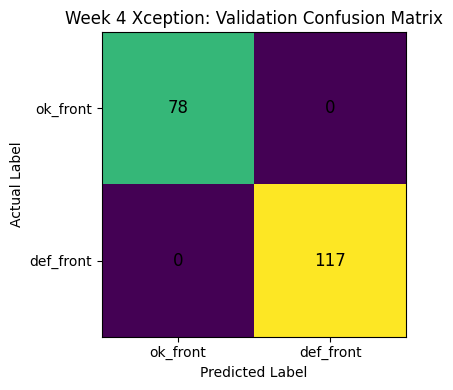

In [18]:

# Contributor: Navatej Patel Cheerneni
# Task: Plot validation confusion matrix

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm)
ax.set_title("Week 4 Xception: Validation Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["ok_front", "def_front"])
ax.set_yticklabels(["ok_front", "def_front"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.savefig(PLOT_DIR / "week4_xception_confusion_matrix.png", dpi=160)
plt.show()



## 10. Compare Xception With Week 3 Baseline

**Contributor:** Raghava Krishna Battu  
This creates a comparison file between Week 4 Xception and Week 3 Custom CNN baseline when the Week 3 result file is available.


In [19]:

# Contributor: Raghava Krishna Battu
# Task: Compare Xception with Week 3 Custom CNN baseline if available

comparison_rows = [{"model": "Xception transfer learning", **xception_metrics}]

possible_week3_paths = [
    Path("/kaggle/working/week3_baseline_cnn/reports/week3_baseline_validation_metrics.json"),
    Path("reports/model_results/week3_baseline_validation_metrics.json"),
    REPORT_DIR / "week3_baseline_validation_metrics.json",
]

for path in possible_week3_paths:
    if path.exists():
        with open(path, "r") as f:
            baseline_metrics = json.load(f)
        comparison_rows.append({"model": "Custom CNN baseline", **baseline_metrics})
        print("Loaded Week 3 baseline metrics from:", path)
        break
else:
    print("Week 3 baseline metrics file not found. Comparison table contains Xception only.")

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

comparison_df.to_csv(REPORT_DIR / "week4_xception_vs_baseline_comparison.csv", index=False)


Week 3 baseline metrics file not found. Comparison table contains Xception only.


,model,threshold,accuracy,defect_precision,defect_recall,f1_defect,roc_auc,pr_auc,training_minutes
0,Xception transfer learning,0.5,1.0,1.0,1.0,1.0,1.0,1.0,1.581567



## 11. Save Xception Model and Metadata

**Contributor:** Tharun Chinnachinnaiahgari  
This saves the Week 4 model and metadata for reproducibility.


In [20]:

# Contributor: Tharun Chinnachinnaiahgari
# Task: Save Xception model and metadata

xception_model.save(MODEL_DIR / "week4_xception_transfer_learning.keras")

metadata = {
    "week": "Week 4",
    "model_name": "Xception transfer learning",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "label_mapping": ID_TO_LABEL,
    "class_weights": CLASS_WEIGHTS,
    "validation_metrics": xception_metrics,
    "training_minutes": training_time / 60,
    "backbone": "Xception",
    "backbone_trainable": False,
    "notes": "Week 4 trains the custom classification head with frozen Xception backbone. Fine-tuning will be performed later."
}

with open(REPORT_DIR / "week4_xception_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved Xception model and metadata.")
print("Model path:", MODEL_DIR / "week4_xception_transfer_learning.keras")
print("Metadata path:", REPORT_DIR / "week4_xception_model_metadata.json")


Saved Xception model and metadata.
Model path: /kaggle/working/week4_xception_transfer_learning/models/week4_xception_transfer_learning.keras
Metadata path: /kaggle/working/week4_xception_transfer_learning/reports/week4_xception_model_metadata.json



## 12. Week 4 Findings

**Contributors:** All Team Members

### What Week 4 Achieved
- Reused the clean data preparation and split process.
- Built a TensorFlow input pipeline for 299 × 299 Xception images.
- Loaded Xception as the main transfer-learning architecture.
- Added a custom binary classification head.
- Trained the classification head with the Xception backbone frozen.
- Saved validation metrics, classification report, confusion matrix and training curves.
- Created a comparison structure against the Week 3 baseline CNN.

### Why This Week Matters
Week 4 directly supports the module requirement to explore and implement modern AI techniques. Xception transfer learning is more advanced than the Week 3 Custom CNN baseline and provides a stronger foundation for later fine-tuning and final evaluation.

### Next Week
Week 5 will compare additional transfer-learning models such as MobileNetV2 and EfficientNetB0 against the Week 3 Custom CNN and Week 4 Xception model.


In [21]:
import shutil
from IPython.display import FileLink, display

folder_path = "/kaggle/working/week4_xception_transfer_learning"
zip_name = "/kaggle/working/week4_xception_transfer_learning"

zip_path = shutil.make_archive(
    base_name=zip_name,
    format="zip",
    root_dir=folder_path
)

print(f"ZIP created: {zip_path}")
display(FileLink(zip_path))

ZIP created: /kaggle/working/week4_xception_transfer_learning.zip


/kaggle/working/week4_xception_transfer_learning.zip